In [1]:
"""モジュール読み込み"""
# 基本
import sys, os
import numpy as np
import matplotlib.pyplot as plt

# spe読み込み用
sys.path.append(r"C:\Users\okaza\pythonenv")
from modules.SpeReadPy.read_spe import SpeReference

# クリップボード操作
import pyperclip

# 画像操作
import cv2

#### 1. データ読み込み

speファイルを読み込む

In [2]:
# speファイルまでのパスを指定
spefile = r"D:\DATA\SPring-8-2025-Dec\Okazaki\UODE36\LF_2\UODE36  20.spe"

# 位置を指定 (推奨：上流か下流どちらかを選択)
pos_range = (0, 200)

# 読み込むフレームを指定
frame = 0

Load file: D:\DATA\SPring-8-2025-Dec\Okazaki\UODE36\LF_2\UODE36  20.spe
pos_range: 0-200
image size: (200, 1340)


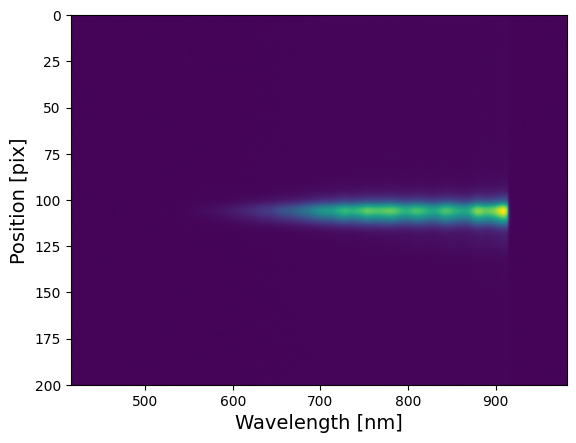

In [3]:
# 読み込み
spe = SpeReference(spefile)

# 画像取得
d = spe.get_data()[0][frame,pos_range[0]:pos_range[1]]
wavelength = spe.get_wavelengths()[0]

# 出力
print("Load file: " + os.path.abspath(spefile))
print("pos_range: {}-{}".format(*pos_range))
print("image size: {}".format(d.shape))
plt.imshow(d, extent = (wavelength[0], wavelength[-1], pos_range[1], pos_range[0]), aspect = "auto")
plt.xlabel("Wavelength [nm]", fontsize = 14)
plt.ylabel("Position [pix]", fontsize = 14)
plt.show()
plt.close()

#### 2. 画像の回転

In [4]:
# 回転角度
rotation_angle = -1.625E-02

rotation angle: -0.01625 degree

Get average: success!


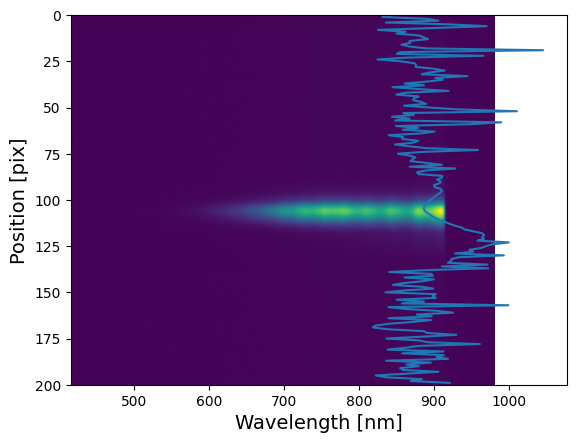

In [5]:
# 回転用行列を作成
retval = cv2.getRotationMatrix2D(np.array(d.T.shape)/2, rotation_angle, 1) # type: ignore

# 回転を実施
dst = cv2.warpAffine(d, retval, d.T.shape)

# 出力1
print("rotation angle: {} degree\n".format(rotation_angle))
pyperclip.copy("{}".format(float(rotation_angle)))

# 強度中心を求める
weighted_average = []
for _ in dst:
    weighted_average.append(
        np.average(np.arange(_.shape[0]), weights = _) # type: ignore
    )
weighted_average = np.array(weighted_average)

# 出力2
print("Get average: success!")
fig, ax = plt.subplots()
ax.imshow(dst, aspect = "auto", extent = (wavelength[0], wavelength[-1], pos_range[1], pos_range[0]))
ax.plot(weighted_average, np.arange(len(weighted_average)))
ax.set_xlabel("Wavelength [nm]", fontsize = 14)
ax.set_ylabel("Position [pix]", fontsize = 14)
plt.show()
plt.close()

#### 3. 回転の適合性確認

強度と強度中心の相関係数を求め、回転の適合性を判断します。

In [6]:
# 相関係数を求める強度の閾値
threshold = 2e5

Correlation coefficient: -4.898215082536971e-07


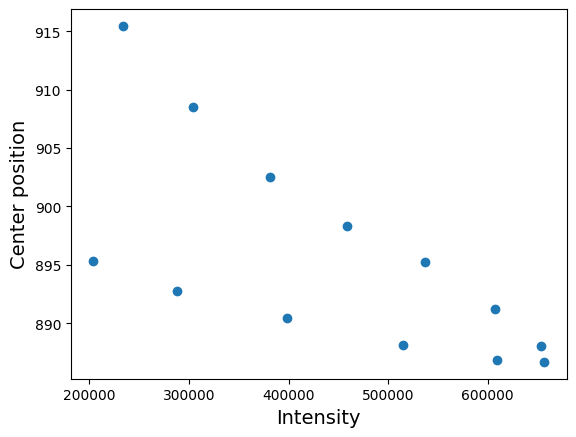

In [7]:
# 強度の合計を求める
sumdata = np.sum(dst, axis = 1)

# 閾値でマスクをする
mask = (sumdata > threshold)

# 相関係数を求める
cov = np.cov(sumdata[mask], weighted_average[mask])
cc = cov[1,0]/cov[0,0]/cov[1,1]

# 出力
print("Correlation coefficient: {}".format(cc))
pyperclip.copy(str(float(cc)))
plt.plot(
    sumdata[mask],
    weighted_average[mask],
    marker = "o",
    lw = 0
)
plt.xlabel("Intensity", fontsize = 14)
plt.ylabel("Center position", fontsize = 14)
plt.show()
plt.close()